# 17 — MRC Benchmark: pretrained baselines vs SALT milestones (UIT-ViQuAD)

Full answerable UIT-ViQuAD 2.0, one harness, SQuAD EM/F1. Compares 6 pretrained encoders
(PhoBERT base/v2/large, XLM-R base/large, ViDeBERTa-base donor) against our staged-WSD
SALT arm at every milestone (100k/500k/1M/2M). **Resumable** — re-run the run cell after a
Colab disconnect; finished (model, seed) rows are skipped.

Engine: `salt3_mrc_benchmark.py` · registry: `salt3_mrc_models.py` · report: `salt3_mrc_report.py`.

## 0. Setup — JRE (for VnCoreNLP word-seg) + libs

In [1]:
%%capture
!apt-get -qq install -y default-jre > /dev/null 2>&1
!pip install -U transformers accelerate datasets evaluate safetensors sentencepiece tokenizers pandas scikit-learn scipy matplotlib tqdm huggingface_hub py_vncorenlp

## 1. Mount Drive, paths, imports

In [ ]:
import sys, importlib
from pathlib import Path
from google.colab import drive; drive.mount('/content/drive')

PROJECT_ROOT = Path('/content/drive/MyDrive/SALT3') if Path('/content/drive/MyDrive').exists() else Path.cwd() / 'SALT3'
CODE = PROJECT_ROOT / 'code'
sys.path.insert(0, str(CODE)); sys.path.insert(0, '/content')

# Force a clean load of the project modules from Drive: assert the file is actually synced
# (clear message instead of importlib.reload's cryptic "spec not found"), then drop any stale
# in-memory copy so the import below re-reads the current file.
for m in ('salt3_common', 'salt3_mrc_benchmark', 'salt3_mrc_models', 'salt3_mrc_report'):
    assert (CODE / f'{m}.py').exists(), f"NOT on Drive: {CODE / (m + '.py')}  ->  upload code/{m}.py to {CODE}"
    sys.modules.pop(m, None)

from salt3_common import ensure_dir
import salt3_mrc_benchmark as bench
import salt3_mrc_models as models
import salt3_mrc_report as report

RUNS_ROOT = PROJECT_ROOT / 'runs' / 'wsd'          # our trained milestones live here
EVAL_DIR  = ensure_dir(PROJECT_ROOT / 'eval' / 'mrc_benchmark')
RESULTS_JSONL = EVAL_DIR / 'mrc_results.jsonl'
print('project:', PROJECT_ROOT); print('runs:', RUNS_ROOT); print('eval out:', EVAL_DIR)

## 2. (optional) CPU smoke checks — engine sanity before the GPU sweep

In [3]:
!python3 {PROJECT_ROOT / 'code' / 'salt3_mrc_benchmark_checks.py'}

MRC benchmark CPU checks
[test_answerable_filter]
  ✓ answerable example parsed
  ✓ impossible example dropped
[test_span_alignment_unsegmented]
  QA rows: 1 kept, drops={'no_answer': 1, 'span_not_found': 0, 'truncated': 0}
  ✓ one answerable row kept
  ✓ decoded gold span == 'hà nội'
  ✓ context_token_mask marks ctx tokens
[test_segment_remap]
  QA rows: 1 kept, drops={'no_answer': 1, 'span_not_found': 0, 'truncated': 0}
  ✓ segmented row kept (span re-found)
  ✓ segmented gold span == 'hà_nội'
[test_slow_wordlevel_path]
  QA rows: 1 kept, drops={'no_answer': 1, 'span_not_found': 0, 'truncated': 0}
  ✓ slow path keeps answerable row
  ✓ slow span maps to context tokens
  ✓ slow decoded span == 'hà nội'


  ✓ slow oracle F1=100
[test_squad_post_eval]
  QA rows: 1 kept, drops={'no_answer': 1, 'span_not_found': 0, 'truncated': 0}
  ✓ oracle reaches F1=100
  ✓ oracle reaches EM=100
[test_neobert_head_forward]
  ✓ neobert head start_logits shape
  ✓ neobert head loss finite
[test_skip_done

## 3. Build the model roster + config
`SEEDS=(42,)` for a fast full-table first pass; expand to `(42,123,456)` for mean±std.

In [ ]:
cfg = bench.MRCConfig(seeds=(42, 123, 456))   # 3 fine-tune seeds on a FIXED val/test split -> mean+/-std (matches MRCConfig default). seed 42 reuses the cached single-seed rows; 123 & 456 re-finetune EVERY model (baselines included). Decay milestone (milestone_5000000_decay) is auto-discovered, priority decay>cooled>stable. For a quick single-seed pass use seeds=(42,).
SPECS = models.build_all_specs(RUNS_ROOT)     # 4 working baselines + auto-discovered SALT milestones (ViDeBERTa donor excluded by default — it scores ~2 F1 in this harness; pass include_donor=True to add it as a reference row)

print(f'{len(SPECS)} models:')
for n, s in SPECS.items():
    tag = f"{s['milestone_docs']//1000}k" if s.get('milestone_docs') else 'pretrained'
    print(f"  {n:18s} family={s['family']:16s} segment={s['segment']!s:5s} {tag}")

## 4. Load UIT-ViQuAD 2.0 (answerable-only)

In [5]:
splits = bench.load_viquad_answerable(seed=42)
print({k: len(v) for k, v in splits.items()})

README.md:   0%|          | 0.00/6.04k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/5.20M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/735k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/28454 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3814 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7301 [00:00<?, ? examples/s]

{'train': 28454, 'validation': 1907, 'test': 1907}


## 5. Run the benchmark — resumable (re-run to continue after a disconnect)

In [6]:
rows = bench.run_benchmark(SPECS, splits, RESULTS_JSONL, cfg=cfg, device='cuda')
print(f'total result rows: {len(rows)}')

  MRC-ViQuAD: PhoBERT-base-v2/seed42 ...


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

...

    -> f1=73.92 em=46.07
  MRC-ViQuAD: SALT-2000k/seed42 ...
  ✓ load_model_safe: all 172 keys loaded successfully
  QA rows: 19041 kept, drops={'no_answer': 9216, 'span_not_found': 0, 'truncated': 197}
  QA rows: 1329 kept, drops={'no_answer': 571, 'span_not_found': 0, 'truncated': 7}


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  QA rows: 1311 kept, drops={'no_answer': 590, 'span_not_found': 0, 'truncated': 6}


Epoch,Training Loss,Validation Loss
1,1.233630,1.217480
2,0.797142,1.351624
3,0.331460,1.608281


    -> f1=74.69 em=47.75
total result rows: 9


## 6. Report — table + learning curve
Writes `mrc_summary.{csv,md,json}` and `mrc_learning_curve.png` into the eval dir.

wrote summary (9 models) -> /content/drive/MyDrive/SALT3/eval/mrc_benchmark
| Model | Family | Params(M) | EM | F1 |
|---|---|---|---|---|
| XLM-R-large | XLM-R | 559 | 52.60±0.00 | 77.91±0.00 |
| PhoBERT-large | PhoBERT | 368 | 51.86±0.00 | 77.83±0.00 |
| PhoBERT-base-v2 | PhoBERT | 134 | 51.32±0.00 | 77.22±0.00 |
| SALT-2000k | SALT (ours) | 245 | 47.75±0.00 | 74.69±0.00 |
| XLM-R-base | XLM-R | 277 | 49.16±0.00 | 74.46±0.00 |
| SALT-500k | SALT (ours) | 245 | 45.92±0.00 | 74.17±0.00 |
| SALT-1000k | SALT (ours) | 245 | 46.07±0.00 | 73.92±0.00 |
| SALT-100k | SALT (ours) | 245 | 44.93±0.00 | 72.11±0.00 |
| ViDeBERTa-base | ViDeBERTa (donor) | 184 | 0.39±0.00 | 2.18±0.00 |


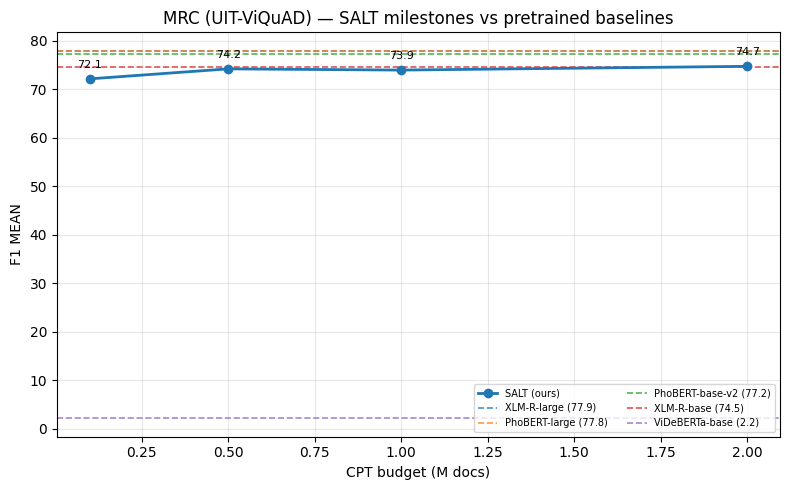

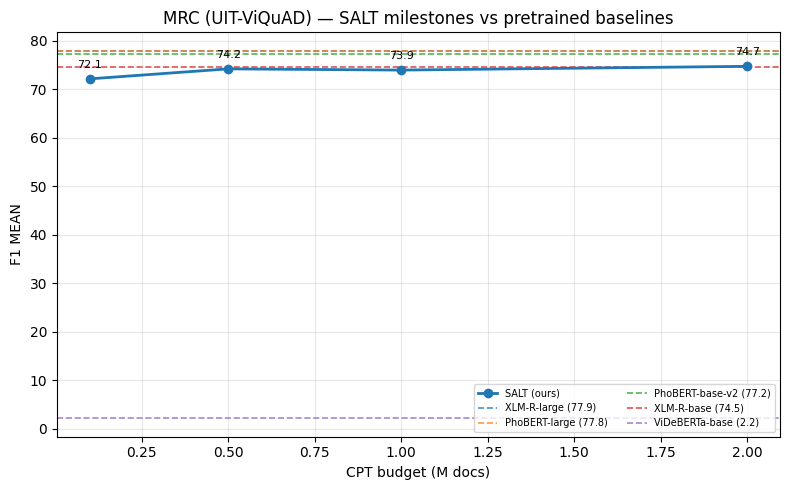

In [7]:
summary = report.write_report(RESULTS_JSONL, EVAL_DIR)
import IPython.display as D
print(report.to_markdown(summary))
report.plot_learning_curve(summary);

## Notes
- **Word-seg:** PhoBERT/ViDeBERTa run on VnCoreNLP-segmented input (auto, via spec `segment=True`); XLM-R and our NeoBERT use raw text. The flag is recorded in every row.
- **Fairness:** all models share lr=2e-5, bs=8, 5 epochs, early-stop on val loss, full ViQuAD. Absolute F1 is now comparable to the ViDeBERTa paper (~80s for PhoBERT).
- **Cost:** ~10 models × seeds on full ViQuAD is heavy; start with `seeds=(42,)`, then expand.
- **Milestones missing weights** are skipped with a warning (partial Drive sync safe).

In [8]:
from google.colab import runtime
runtime.unassign()